# From Prediction to Causality: Choosing the Right Tool for Attribution and Driver Analysis

## Imports

In [ ]:
import pandas as pd 

# Data Visualization
import matplotlib.pyplot as plt

# Data Download
import kagglehub 

ModuleNotFoundError: No module named 'sklearn'

## Load Data 

In [ ]:
# Get the path to the downloaded files
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pwcuser\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [7]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## EDA

### Dataset Overview 

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.shape

(7043, 21)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Missing Values Check

In [14]:
df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Churn Distribution

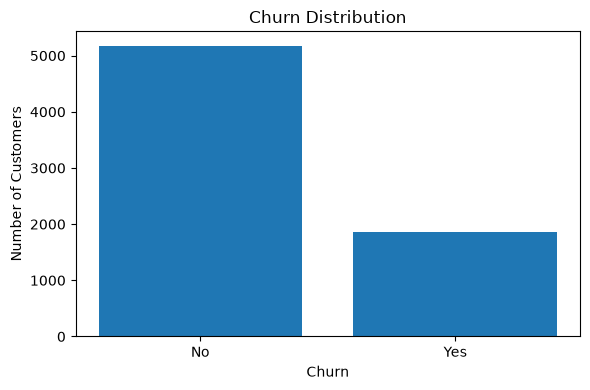

In [17]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Churn Rate

In [18]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Churn Rate by Contract Type 

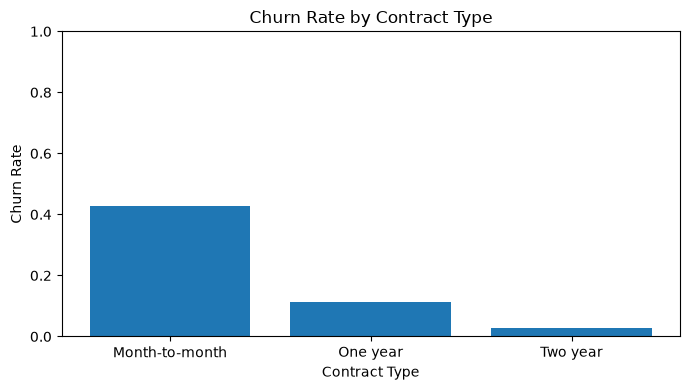

In [22]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(contract_churn.index, contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Churn by Tenure

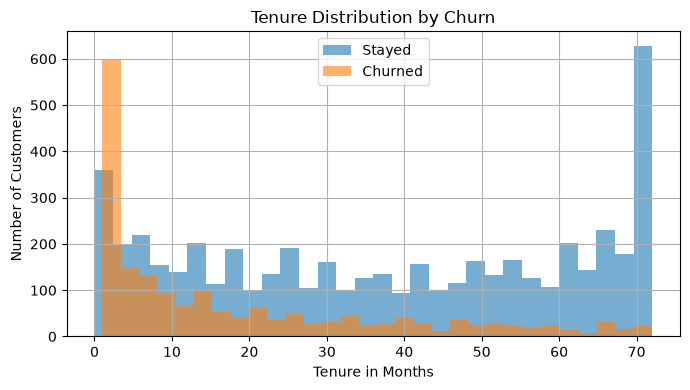

In [19]:
plt.figure(figsize=(7, 4))

df[df["Churn"] == "No"]["tenure"].hist(bins=30, alpha=0.6, label="Stayed")
df[df["Churn"] == "Yes"]["tenure"].hist(bins=30, alpha=0.6, label="Churned")

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

### Churn by Monthly Charges

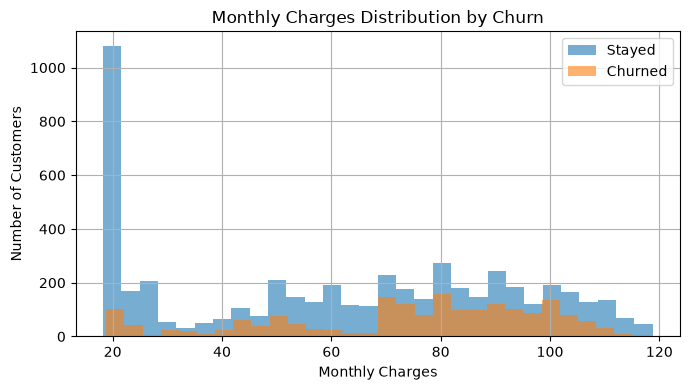

In [20]:
plt.figure(figsize=(7, 4))

df[df["Churn"] == "No"]["MonthlyCharges"].hist(bins=30, alpha=0.6, label="Stayed")
df[df["Churn"] == "Yes"]["MonthlyCharges"].hist(bins=30, alpha=0.6, label="Churned")

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

### Churn by Internet Service

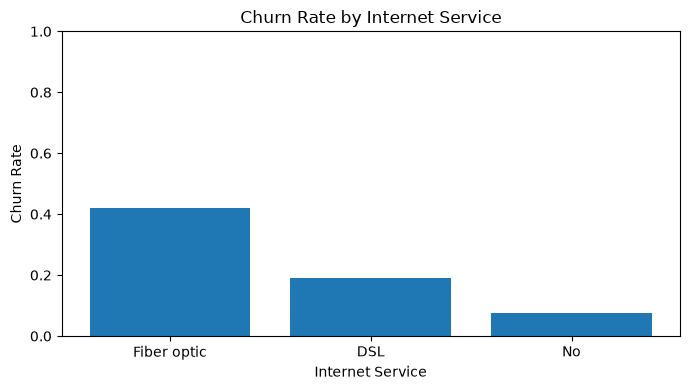

In [21]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(internet_churn.index, internet_churn.values)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Conclusion

The basic EDA shows that churn is not random. Churn appears to vary meaningfully by contract type, tenure, monthly charges, and internet service. This gives us a useful starting point for prediction. However, at this stage we are only identifying patterns and associations. We are not yet explaining the model, and we are definitely not making causal claims.